In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 00 — Data Preprocessing

Loads the raw Kaggle *Acquire Valued Shoppers* CSVs and produces a clean, feature-rich tabular dataset with a temporal key (`offerdate`), ready for the rolling-window experiment.

**Input:** `shoppers_data.zip`  
**Output:**
- `data/processed/X.parquet` — feature matrix  
- `data/processed/Y.npy` — binary labels (1 = repeater)  
- `data/processed/meta.parquet` — offerdate + customer id per row  
- `data/processed/feature_names.json`

**Runtime note:** Transaction streaming is the slowest step (~10–30 min, I/O-bound, runs once then cached). Feature engineering uses a row-by-row `compute_features` loop (~5–10 rows/s; 5–15 hours for the full 160 k rows on a laptop). All expensive steps write a cache file so subsequent runs are near-instant.

In [2]:
import os
import json
import zipfile
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import timedelta
import matplotlib.pyplot as plt  # moved here from a later cell to keep all imports at the top

# ── Paths ──────────────────────────────────────────────────────────────────
# WORKSPACE : root folder for all notebook inputs/outputs
# ZIP_PATH  : original Kaggle archive (never modified)
# RAW_DIR   : extracted CSVs land here (write-once after first extraction)
# CACHE_DIR : heavyweight intermediate files; allows skipping expensive steps on re-runs
# PROC_DIR  : final artefacts consumed by downstream notebooks (X, Y, meta, feature_names)
WORKSPACE = Path('/content/drive/MyDrive/Thesis/Shoppers_workspace')

ZIP_PATH  = Path('/content/drive/MyDrive/Thesis/Shoppers_workspace/shoppers_data.zip')
RAW_DIR     = WORKSPACE / 'data' / 'raw'
CACHE_DIR   = WORKSPACE / 'data' / 'cache'
PROC_DIR    = WORKSPACE / 'data' / 'processed'

for d in [RAW_DIR, CACHE_DIR, PROC_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Paths OK')

Paths OK


## 1. Extract zip

In [3]:
# A hidden marker file (.extracted) acts as a cheap "already done" flag.
# This prevents re-extracting ~2-3 GB of gzipped data on every notebook restart.
marker = RAW_DIR / '.extracted'
if not marker.exists():
    print(f'Extracting {ZIP_PATH} ...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(RAW_DIR)
    marker.touch()
    print('Extraction complete.')
else:
    print('Already extracted, skipping.')

print('Files in RAW_DIR:')
for f in sorted(RAW_DIR.iterdir()):
    print(f'  {f.name}')

Already extracted, skipping.
Files in RAW_DIR:
  .extracted
  offers.csv.gz
  sampleSubmission.csv.gz
  testHistory.csv.gz
  trainHistory.csv.gz
  transactions.csv.gz


## 2. Load trainHistory and offers

In [4]:
# ── trainHistory ────────────────────────────────────────────────────────────
# One row per (customer, offer) pair in the training set.
# Column descriptions:
#   id          : unique anonymised customer identifier
#   chain       : retail chain code where the offer was distributed
#   offer       : offer identifier — foreign key to offers.csv
#   market      : geographic market code
#   repeattrips : number of shopping trips the customer made 60 days AFTER
#                 receiving the offer (used to derive the target label)
#   repeater    : 't' if the customer returned at all (repeattrips > 0), 'f' otherwise
#                 → this is our binary prediction target
#   offerdate   : calendar date the offer was shown to the customer
train_hist_path = RAW_DIR / 'trainHistory.csv.gz'
if not train_hist_path.exists():
    # Some zips put files in a subdirectory; search recursively as a fallback
    candidates = list(RAW_DIR.rglob('trainHistory.csv.gz')) + list(RAW_DIR.rglob('trainHistory.csv'))
    train_hist_path = candidates[0] if candidates else train_hist_path

train = pd.read_csv(train_hist_path, parse_dates=['offerdate'])
print(f'trainHistory: {train.shape}')
print(train.dtypes)
train.head(3)

trainHistory: (160057, 7)
id                      int64
chain                   int64
offer                   int64
market                  int64
repeattrips             int64
repeater               object
offerdate      datetime64[ns]
dtype: object


,id,chain,offer,market,repeattrips,repeater,offerdate
0,86246,205,1208251,34,5,t,2013-04-24
1,86252,205,1197502,34,16,t,2013-03-27
2,12682470,18,1197502,11,0,f,2013-03-28


In [5]:
# ── offers ───────────────────────────────────────────────────────────────────
# Describes the 37 distinct coupons/promotions used in the experiment.
# Column descriptions:
#   offer      : offer identifier — primary key, joins to trainHistory.offer
#   category   : product category code of the offered item
#   quantity   : minimum purchase quantity required to redeem the offer
#   company    : manufacturer/company identifier for the offered product
#   offervalue : face value of the coupon in USD (e.g. 0.75 = 75-cent discount)
#   brand      : brand identifier of the offered product
offers_path = RAW_DIR / 'offers.csv.gz'
if not offers_path.exists():
    candidates = list(RAW_DIR.rglob('offers.csv.gz')) + list(RAW_DIR.rglob('offers.csv'))
    offers_path = candidates[0] if candidates else offers_path

offers = pd.read_csv(offers_path)
print(f'offers: {offers.shape}')
offers.head(3)

offers: (37, 6)


,offer,category,quantity,company,offervalue,brand
0,1190530,9115,1,108500080,5.00,93904
1,1194044,9909,1,107127979,1.00,6732
2,1197502,3203,1,106414464,0.75,13474


In [6]:
# ── Merge offers onto trainHistory ───────────────────────────────────────────
# Left join: keeps all 160 k training rows; unmatched offers would produce NaN
# (in practice every offer in trainHistory has a matching row in offers.csv).
df = train.merge(offers, on='offer', how='left')

# Binary target: map the 't'/'f' string flag → integer 1/0
#   1 = "repeater"     (customer visited the store again after seeing the offer)
#   0 = "non-repeater" (customer did not return)
df['label'] = (df['repeater'] == 't').astype(np.int8)

print(f'Merged shape: {df.shape}')
print(f'Label distribution:\n{df["label"].value_counts(normalize=True).round(4)}')
print(f'\nOffer date range: {df["offerdate"].min()} → {df["offerdate"].max()}')

# Collect the set of customer IDs present in training — used in the next step
# to discard irrelevant rows from the 349 M-row transactions file.
customer_ids = set(df['id'].unique())
print(f'\nUnique customers: {len(customer_ids):,}')

Merged shape: (160057, 13)
Label distribution:
label
0    0.7286
1    0.2714
Name: proportion, dtype: float64

Offer date range: 2013-03-01 00:00:00 → 2013-04-30 00:00:00

Unique customers: 160,057


## 3. Load and filter transactions

The transactions file has ~349 M rows. We stream it in chunks, keep only rows for customers in our training set, and cache the result.

In [7]:
tx_cache = CACHE_DIR / 'transactions_filtered.parquet'

if tx_cache.exists():
    print('Loading cached filtered transactions ...')
    tx = pd.read_parquet(tx_cache)
    print(f'Loaded: {tx.shape}')
else:
    tx_path = RAW_DIR / 'transactions.csv.gz'
    if not tx_path.exists():
        candidates = list(RAW_DIR.rglob('transactions.csv.gz')) + list(RAW_DIR.rglob('transactions.csv'))
        tx_path = candidates[0] if candidates else tx_path

    print(f'Streaming {tx_path} in chunks ...')
    chunks = []
    # ── Chunk size raised from 500 k → 2 M rows ────────────────────────────
    # Fewer Python-loop iterations (175 vs 700) reduces per-chunk overhead.
    # 2 M rows × ~20 bytes/row ≈ 40 MB in RAM per chunk — well within budget.
    chunk_size = 10_000_000
    total_rows = 0
    kept_rows  = 0

    for i, chunk in enumerate(pd.read_csv(
        tx_path,
        chunksize=chunk_size,
        # ── Date parsing deliberately OMITTED here ──────────────────────────
        # parse_dates on every row of the full 349 M-row file costs ~40 min.
        # We keep 'date' as a raw string during streaming, then parse it once
        # after filtering — converting only the ~113 M kept rows instead of all 349 M.
        dtype={
            'id':              'int32',
            'chain':           'int16',
            'dept':            'int16',
            'category':        'int32',
            'company':         'int64',
            'brand':           'int32',
            'purchasequantity':'int32',
            'purchaseamount':  'float32',
            'date':            'str',    # kept as string; parsed below after filtering
        }
    )):
        total_rows += len(chunk)
        # Filter to only customers in our training set — keeps ~32 % of rows
        filtered = chunk[chunk['id'].isin(customer_ids)]
        kept_rows += len(filtered)
        if len(filtered) > 0:
            chunks.append(filtered)
        if (i + 1) % 20 == 0:
            print(f'  Processed {total_rows:,} rows, kept {kept_rows:,} ...')

    tx = pd.concat(chunks, ignore_index=True)

    # Parse dates once, on the ~113 M filtered rows only (vs 349 M during streaming).
    print('Parsing dates on filtered rows ...')
    tx['date'] = pd.to_datetime(tx['date'])

    print(f'\nDone. Total rows: {total_rows:,} → kept: {tx.shape[0]:,}')

    # Persist filtered transactions; subsequent runs load this instead of re-streaming
    tx.to_parquet(tx_cache, index=False)
    print(f'Cached to {tx_cache}')

Loading cached filtered transactions ...
Loaded: (113631739, 11)


In [8]:
# Sanity-check the filtered transactions table.
# transactions columns:
#   id              : customer identifier (matches trainHistory.id)
#   chain           : retail chain code
#   dept            : department code within the store
#   category        : product category code
#   company         : manufacturer/company identifier
#   brand           : brand identifier
#   date            : purchase date
#   purchasequantity: number of units bought (can be 0 or negative for returns)
#   purchaseamount  : total spend in USD for that line item
print(tx.dtypes)
print(f'\nTransaction date range: {tx["date"].min()} → {tx["date"].max()}')
tx.head(3)

id                           int32
chain                        int16
dept                         int16
category                     int32
company                      int64
brand                        int32
date                datetime64[ns]
productsize                float64
productmeasure              object
purchasequantity             int32
purchaseamount             float32
dtype: object



Transaction date range: 2012-03-02 00:00:00 → 2013-07-23 00:00:00


,id,chain,dept,category,company,brand,date,productsize,productmeasure,purchasequantity,purchaseamount
0,86246,205,7,707,1078778070,12564,2012-03-02,12.0,OZ,1,7.59
1,86246,205,63,6319,107654575,17876,2012-03-02,64.0,OZ,1,1.59
2,86246,205,97,9753,1022027929,0,2012-03-02,1.0,CT,1,5.99


## 4. Feature Engineering

Replicates `ecom-offers.py` from the TabRed benchmark exactly:

1. **Join** filtered transactions with each customer's offer info (broadcasts `offerdate`, `company`, `category`, `brand`, `offervalue` onto every transaction row).
2. Compute `date_diff = offerdate - date` (positive = transaction happened **before** the offer).
3. **Vectorised `groupby('id').sum()`** — no Python loops over customers.

**Windows:** `[1, 3, 7, 14, 21, 28, 60, 90, 120, 150, 180]` days  
**Scopes:** `company` / `category` / `brand`  
**Metrics per (scope, window):** count, quantity-sum, amount-sum  
**X_num** (113 features): total_spend · offervalue · day_of_week/month/year · 9 all-time · 99 windowed  
**X_bin** (6 features): never-bought flags + combo flags (TabRed spec)


In [9]:
# Invalidate old feature cache (feature set has changed)
for old in ['features_raw.parquet']:
    p = CACHE_DIR / old
    if p.exists():
        p.unlink()
        print(f'Removed stale cache: {old}')

# Join filtered transactions with customer-offer metadata
# Mirrors: data_transactions.join(data_train_offer, on='id') in ecom-offers.py
# df has one row per customer with their offer's company/category/brand.
offer_meta = df[['id', 'offerdate', 'company', 'category', 'brand', 'offervalue']].rename(
    columns={'company': 'company_right', 'category': 'category_right', 'brand': 'brand_right'}
)

tx_offer = tx.merge(offer_meta, on='id', how='inner')

# date_diff = offerdate - date  (ecom-offers.py: (offerdate - date).dt.total_days())
tx_offer['date_diff'] = (tx_offer['offerdate'] - tx_offer['date']).dt.days

print(f'tx_offer shape   : {tx_offer.shape}')
print(f'Unique customers : {tx_offer["id"].nunique():,}')
print(f'date_diff range  : {tx_offer["date_diff"].min()} to {tx_offer["date_diff"].max()}')
print(f'date_diff mean   : {tx_offer["date_diff"].mean():.1f}  (positive = historical tx)')


Removed stale cache: features_raw.parquet
tx_offer shape   : (113631739, 17)
Unique customers : 93,681
date_diff range  : -116 to 424
date_diff mean   : 199.3  (positive = historical tx)


In [ ]:
WINDOWS = [1, 3, 7, 14, 21, 28, 60, 90, 120, 150, 180]
SCOPES  = [
    ('bought_company',  'company',  'company_right'),
    ('bought_category', 'category', 'category_right'),
    ('bought_brand',    'brand',    'brand_right'),
]

# Pre-extract numpy arrays once for speed
ids   = tx_offer['id'].values
ddiff = tx_offer['date_diff'].values
qty   = tx_offer['purchasequantity'].values.astype(np.float64)
amt   = tx_offer['purchaseamount'].values.astype(np.float64)

# Pre-offer mask: only include transactions that occurred BEFORE (or on) the offer date.
# date_diff = offerdate - date, so ddiff >= 0 means a historical transaction.
# Rows with ddiff < 0 are post-offer transactions; including them would constitute
# direct temporal leakage into every feature (total_spend, all-time, and windowed).
pre = (ddiff >= 0).astype(np.float64)

# Pre-compute boolean scope filter arrays
scope_filters = {
    fn: (tx_offer[tc].values == tx_offer[oc].values).astype(np.float64)
    for fn, tc, oc in SCOPES
}

feat_parts = []  # list of DataFrames indexed by customer id

# total_spend (pre-offer transactions only)
feat_parts.append(
    pd.DataFrame({'total_spend': pre * amt}, index=ids).groupby(level=0).sum()
)
print('total_spend : done')

# All-time scope aggregations (pre-offer only, no date window)
for fn, tc, oc in SCOPES:
    f  = scope_filters[fn]
    fp = f * pre   # scope match AND pre-offer
    feat_parts.append(
        pd.DataFrame({
            f'has_{fn}':   fp,
            f'has_{fn}_q': fp * qty,
            f'has_{fn}_a': fp * amt,
        }, index=ids).groupby(level=0).sum()
    )
    print(f'all-time {fn}: done')

# Time-windowed aggregations (pre-offer AND within d days before offer date)
# Mirrors ecom-offers.py: date_diffs = [pl.col('date_diff').lt(d) for d in WINDOWS]
# but adds the ddiff >= 0 guard to exclude post-offer transactions.
for d in WINDOWS:
    w = ((ddiff >= 0) & (ddiff < d)).astype(np.float64)
    for fn, tc, oc in SCOPES:
        f  = scope_filters[fn]
        fw = f * w
        feat_parts.append(
            pd.DataFrame({
                f'has_{fn}_{d}':   fw,
                f'has_{fn}_q_{d}': fw * qty,
                f'has_{fn}_a_{d}': fw * amt,
            }, index=ids).groupby(level=0).sum()
        )
    print(f'window d={d:>3d}: done')

agg_features = pd.concat(feat_parts, axis=1)
print(f'\nAggregated feature matrix: {agg_features.shape} (expected 109 columns)')

assert df['id'].is_unique, "df must contain exactly one row per id"
n_post = int((tx_offer['date_diff'] < 0).sum())
print(f'Post-offer transactions in raw join: {n_post:,} (excluded from all aggregations by pre-offer mask)')

total_spend : done
all-time bought_company: done
all-time bought_category: done
all-time bought_brand: done
window d=  1: done
window d=  3: done
window d=  7: done
window d= 14: done
window d= 21: done
window d= 28: done
window d= 60: done
window d= 90: done
window d=120: done
window d=150: done
window d=180: done

Aggregated feature matrix: (93681, 109) (expected 109 columns)
Must not be non-zero:  245


In [11]:
# Time features derived from offerdate (one row per customer-offer pair)
time_feats = pd.DataFrame({
    'offervalue':   df['offervalue'].values.astype(np.float32),
    'day_of_week':  df['offerdate'].dt.weekday.values.astype(np.float32),
    'day_of_month': df['offerdate'].dt.day.values.astype(np.float32),
    'day_of_year':  df['offerdate'].dt.day_of_year.values.astype(np.float32),
}, index=df['id'].values)

# Merge aggregated features back to df row order
# Left-join preserves all df rows; customers without transactions get 0.
combined = (
    df[['id']]
    .merge(agg_features.reset_index().rename(columns={'index': 'id'}), on='id', how='left')
    .merge(time_feats.reset_index().rename(columns={'index': 'id'}),   on='id', how='left')
    .drop(columns='id')
    .fillna(0.0)
)
assert len(combined) == len(df)

# X_num: all numerical features
# Mirrors TabRed: data.select(cols not in ['id','target','offerdate']).cast(Float32)
num_cols = (
    ['total_spend', 'offervalue', 'day_of_week', 'day_of_month', 'day_of_year']
    + [c for c in agg_features.columns if c != 'total_spend']
)
X_num = combined[num_cols].astype(np.float32)

# X_bin: binary indicator features — exact TabRed spec
X_bin = pd.DataFrame({
    'never_bought_company':  (combined['has_bought_company']  == 0).astype(np.float32),
    'never_bought_category': (combined['has_bought_category'] == 0).astype(np.float32),
    'never_bought_brand':    (combined['has_bought_brand']    == 0).astype(np.float32),
    'has_bought_brand_company_category': (
        (combined['has_bought_brand']    != 0) &
        (combined['has_bought_category'] != 0) &
        (combined['has_bought_company']  != 0)
    ).astype(np.float32),
    'has_bought_brand_category': (
        (combined['has_bought_brand']    != 0) &
        (combined['has_bought_category'] != 0)
    ).astype(np.float32),
    'has_bought_brand_company': (
        (combined['has_bought_brand']    != 0) &
        (combined['has_bought_company']  != 0)
    ).astype(np.float32),
})

print(f'X_num : {X_num.shape}  (expected (n, 113))')
print(f'X_bin : {X_bin.shape}  (expected (n, 6))')
print('\nX_num columns:')
for c in X_num.columns: print(f'  {c}')
print('\nX_bin columns:')
for c in X_bin.columns: print(f'  {c}')


X_num : (160057, 113)  (expected (n, 113))
X_bin : (160057, 6)  (expected (n, 6))

X_num columns:
  total_spend
  offervalue
  day_of_week
  day_of_month
  day_of_year
  has_bought_company
  has_bought_company_q
  has_bought_company_a
  has_bought_category
  has_bought_category_q
  has_bought_category_a
  has_bought_brand
  has_bought_brand_q
  has_bought_brand_a
  has_bought_company_1
  has_bought_company_q_1
  has_bought_company_a_1
  has_bought_category_1
  has_bought_category_q_1
  has_bought_category_a_1
  has_bought_brand_1
  has_bought_brand_q_1
  has_bought_brand_a_1
  has_bought_company_3
  has_bought_company_q_3
  has_bought_company_a_3
  has_bought_category_3
  has_bought_category_q_3
  has_bought_category_a_3
  has_bought_brand_3
  has_bought_brand_q_3
  has_bought_brand_a_3
  has_bought_company_7
  has_bought_company_q_7
  has_bought_company_a_7
  has_bought_category_7
  has_bought_category_q_7
  has_bought_category_a_7
  has_bought_brand_7
  has_bought_brand_q_7
  has_bou

## 5. Assemble and save final dataset

In [12]:
# Concatenate X_num + X_bin -> single feature matrix X used by downstream notebooks.
X = pd.concat([X_num, X_bin], axis=1)
Y = df['label'].values.astype(np.int8)
meta = df[['id', 'offerdate', 'offer', 'chain', 'market']].reset_index(drop=True)

feature_names     = list(X.columns)
num_feature_names = list(X_num.columns)
bin_feature_names = list(X_bin.columns)

assert len(X) == len(Y) == len(meta), 'Row count mismatch!'
assert not X.isnull().any().any(), 'NaN values found in X!'

print(f'X     : {X.shape}')
print(f'Y     : {Y.shape}  positives={Y.sum():,} ({Y.mean():.3%})')
print(f'meta  : {meta.shape}')


X     : (160057, 119)
Y     : (160057,)  positives=43,438 (27.139%)
meta  : (160057, 5)


In [13]:
# ── Descriptive statistics ────────────────────────────────────────────────
# A quick check for obviously wrong values (e.g. negative spend, huge outliers).
print('Feature summary stats:')
X.describe().T[['mean', 'std', 'min', 'max']].round(3)

Feature summary stats:


,mean,std,min,max
total_spend,3334.983,142950.188,-5953.67,48321664.0
offervalue,1.255,0.525,0.75,3.0
day_of_week,2.621,1.937,0.00,6.0
day_of_month,19.004,9.633,1.00,31.0
day_of_year,96.165,15.090,60.00,120.0
...,...,...,...,...
never_bought_category,0.702,0.457,0.00,1.0
never_bought_brand,0.763,0.426,0.00,1.0
has_bought_brand_company_category,0.122,0.328,0.00,1.0
has_bought_brand_category,0.138,0.345,0.00,1.0


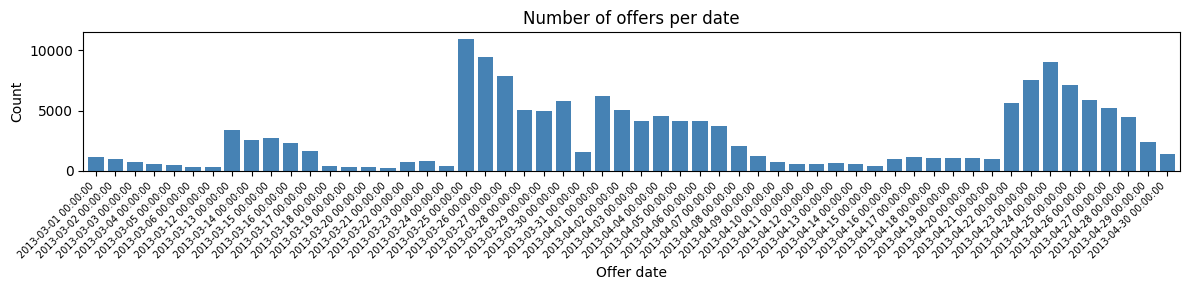

In [14]:
# Plot the number of (customer, offer) rows per offer date.
# A uniform-ish distribution is expected; spikes may indicate batch offer events.
fig, ax = plt.subplots(figsize=(12, 3))
meta['offerdate'].value_counts().sort_index().plot(ax=ax, kind='bar', width=0.8, color='steelblue')
ax.set_title('Number of offers per date')
ax.set_xlabel('Offer date')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.savefig(PROC_DIR / 'offer_date_distribution.png', dpi=120)   # use PROC_DIR for consistency
plt.show()

In [15]:
X.to_parquet(PROC_DIR / 'X.parquet',     index=False)
X_num.to_parquet(PROC_DIR / 'X_num.parquet', index=False)
X_bin.to_parquet(PROC_DIR / 'X_bin.parquet', index=False)
np.save(PROC_DIR / 'Y.npy', Y)
meta.to_parquet(PROC_DIR / 'meta.parquet', index=False)

with open(PROC_DIR / 'feature_names.json', 'w') as f:
    json.dump({'all': feature_names, 'num': num_feature_names, 'bin': bin_feature_names}, f, indent=2)

print('Saved:')
for fname in ['X.parquet', 'X_num.parquet', 'X_bin.parquet', 'Y.npy', 'meta.parquet', 'feature_names.json']:
    p = PROC_DIR / fname
    print(f'  {fname:<32s} {p.stat().st_size / 1e6:6.1f} MB')


Saved:
  X.parquet                           6.6 MB
  X_num.parquet                       6.5 MB
  X_bin.parquet                       0.1 MB
  Y.npy                               0.2 MB
  meta.parquet                        1.5 MB
  feature_names.json                  0.0 MB


## 6. Verification

In [16]:
X_check    = pd.read_parquet(PROC_DIR / 'X.parquet')
Y_check    = np.load(PROC_DIR / 'Y.npy')
meta_check = pd.read_parquet(PROC_DIR / 'meta.parquet')

with open(PROC_DIR / 'feature_names.json') as f:
    fn_check = json.load(f)

assert X_check.shape[0] == Y_check.shape[0] == meta_check.shape[0], 'Row count mismatch!'
assert not X_check.isnull().any().any(), 'NaN values in X!'
assert X_check.shape[1] == len(fn_check['all']), 'Column count mismatch!'
assert len(fn_check['num']) == 113, f"Expected 113 num features, got {len(fn_check['num'])}"
assert len(fn_check['bin']) == 6,   f"Expected 6 bin features, got {len(fn_check['bin'])}"

print(f'X     : {X_check.shape}  ({len(fn_check["num"])} num + {len(fn_check["bin"])} bin)')
print(f'Y     : {Y_check.shape}  positives={Y_check.sum():,} ({Y_check.mean():.3%})')
print(f'Date range: {meta_check["offerdate"].min()} -> {meta_check["offerdate"].max()}')
print('All checks passed.')


X     : (160057, 119)  (113 num + 6 bin)
Y     : (160057,)  positives=43,438 (27.139%)
Date range: 2013-03-01 00:00:00 -> 2013-04-30 00:00:00
All checks passed.


---
## 7. Exploratory Data Analysis

> **Goal of this section:** build intuition about the data *before* modelling.  
> We answer: What are we predicting? Who are the customers? What do the offers look like? What does the transaction history tell us?

### What is this dataset?

This is the Kaggle *Acquire Valued Shoppers* challenge (2014).  
A grocery retailer sends personalised coupons to customers and wants to predict — **before** sending the coupon — whether a customer will become a "repeater": someone who returns to the store at least once within 60 days of receiving the offer.

| File | Description |
|------|-------------|
| `trainHistory` | One row per (customer, offer). Contains the target label `repeater`. |
| `offers` | Catalogue of the 37 distinct promotions (category, brand, value). |
| `transactions` | Full purchase history (~349 M rows) used to build behavioural features. |

**Prediction task:** Binary classification — given a customer's historical transaction behaviour and an offer's characteristics, predict whether the customer will be a repeater (`label = 1`).

TRAINING SET OVERVIEW
Total (customer, offer) pairs : 160,057
Unique customers              : 160,057
Unique offers                 : 24
Unique retail chains          : 130
Unique markets                : 34
Offer date range              : 2013-03-01 → 2013-04-30

LABEL DISTRIBUTION
-----------------------------------
  Non-repeater (0)    : 116,619  (72.9 %)
  Repeater (1)        :  43,438  (27.1 %)

Class imbalance ratio  : 2.7:1  (non-repeater : repeater)

→ The dataset is imbalanced (~73 % non-repeater vs ~27 % repeater).
  Consider class weights, SMOTE, or AUC/F1 as the primary metric.


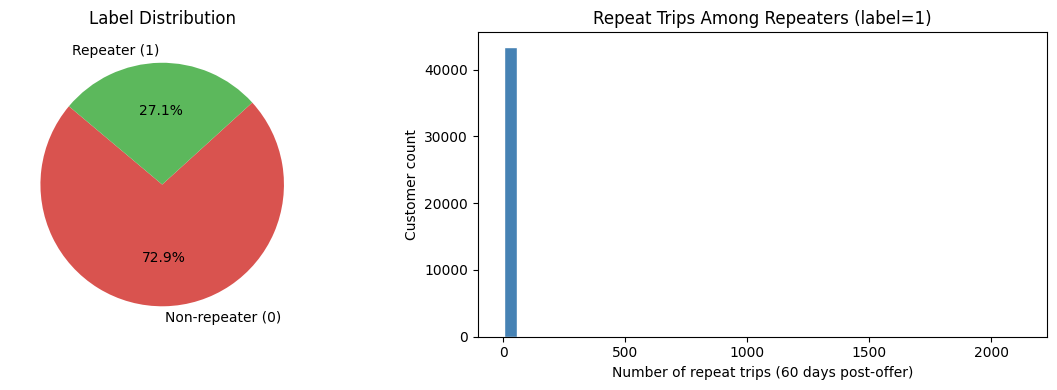


Repeat trips stats (repeaters only):
count    43438.0
mean         2.4
std         12.9
min          1.0
25%          1.0
50%          1.0
75%          2.0
max       2124.0
Name: repeattrips, dtype: float64


In [17]:
# ── 7.1 Training set overview ────────────────────────────────────────────────
print("=" * 55)
print("TRAINING SET OVERVIEW")
print("=" * 55)
print(f"Total (customer, offer) pairs : {len(df):,}")
print(f"Unique customers              : {df['id'].nunique():,}")
print(f"Unique offers                 : {df['offer'].nunique():,}")
print(f"Unique retail chains          : {df['chain'].nunique():,}")
print(f"Unique markets                : {df['market'].nunique():,}")
print(f"Offer date range              : {df['offerdate'].min().date()} → {df['offerdate'].max().date()}")
print()

# ── Label (class) distribution ───────────────────────────────────────────────
# Class imbalance is important for model selection and evaluation metric choice.
label_counts = df['label'].value_counts().sort_index()
label_pct    = df['label'].value_counts(normalize=True).sort_index() * 100

print("LABEL DISTRIBUTION")
print("-" * 35)
for lbl, cnt, pct in zip(label_counts.index, label_counts.values, label_pct.values):
    name = "Repeater (1)" if lbl == 1 else "Non-repeater (0)"
    print(f"  {name:20s}: {cnt:7,}  ({pct:.1f} %)")

print()
print(f"Class imbalance ratio  : {label_counts[0]/label_counts[1]:.1f}:1  (non-repeater : repeater)")
print()
print("→ The dataset is imbalanced (~73 % non-repeater vs ~27 % repeater).")
print("  Consider class weights, SMOTE, or AUC/F1 as the primary metric.")

# Pie chart of label distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(
    label_counts.values,
    labels=['Non-repeater (0)', 'Repeater (1)'],
    autopct='%1.1f%%',
    colors=['#d9534f', '#5cb85c'],
    startangle=140,
)
axes[0].set_title('Label Distribution')

# Repeat-trips distribution among repeaters
repeaters = df[df['label'] == 1]['repeattrips']
axes[1].hist(repeaters, bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Repeat Trips Among Repeaters (label=1)')
axes[1].set_xlabel('Number of repeat trips (60 days post-offer)')
axes[1].set_ylabel('Customer count')

plt.tight_layout()
plt.show()

print(f"\nRepeat trips stats (repeaters only):")
print(repeaters.describe().round(1))

OFFERS CATALOGUE SUMMARY
Total unique offers        : 37
Unique categories offered  : 20
Unique brands offered      : 19
Unique companies offered   : 18

Offer value range          : $0.75  →  $5.00
Median offer value         : $1.50
Quantity requirement range : 1 – 2 unit(s)

Customers per offer (top 10):
         category  brand  offervalue  quantity  n_customers
offer                                                      
1197502      3203  13474        0.75         1      45652.0
1208329      2119   6926        1.00         1      18767.0
1203052      9909  28840        1.00         1      15337.0
1208251      2202   3718        2.00         1      15028.0
1199256      4401  13791        2.00         1       7971.0
1204576      5616  15889        1.00         1       7293.0
1199258      4401  13791        2.00         1       7037.0
1194044      9909   6732        1.00         1       6810.0
1208501      6202  64486        1.50         1       6643.0
1200581      1726   7668        

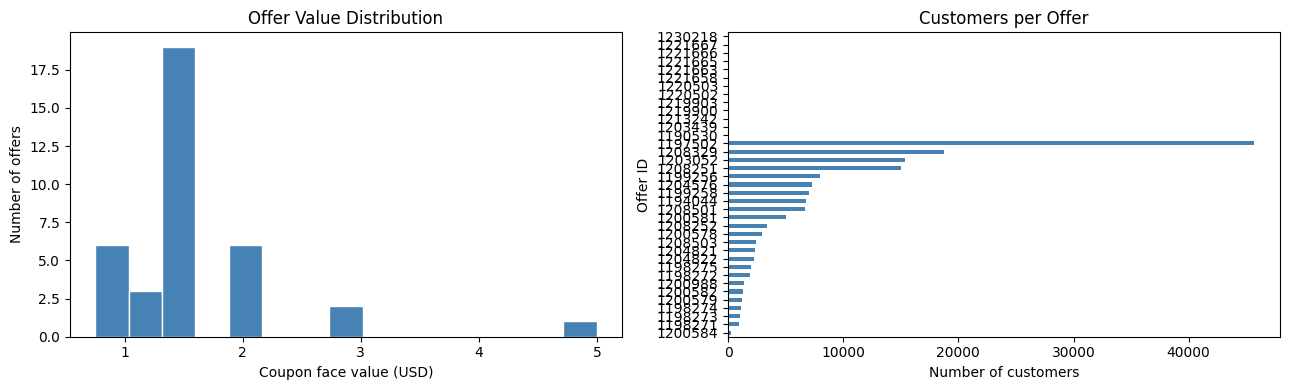

In [18]:
# ── 7.2 Offers catalogue ────────────────────────────────────────────────────
# There are only 37 distinct offers. Understanding their spread helps explain
# which features will be most informative.
print("OFFERS CATALOGUE SUMMARY")
print("=" * 55)
print(f"Total unique offers        : {len(offers)}")
print(f"Unique categories offered  : {offers['category'].nunique()}")
print(f"Unique brands offered      : {offers['brand'].nunique()}")
print(f"Unique companies offered   : {offers['company'].nunique()}")
print(f"\nOffer value range          : ${offers['offervalue'].min():.2f}  →  ${offers['offervalue'].max():.2f}")
print(f"Median offer value         : ${offers['offervalue'].median():.2f}")
print(f"Quantity requirement range : {offers['quantity'].min()} – {offers['quantity'].max()} unit(s)")
print()

# How many customers received each offer?
offer_counts = df['offer'].value_counts().rename('n_customers')
offers_eda = offers.set_index('offer').join(offer_counts).sort_values('n_customers', ascending=False)
print("Customers per offer (top 10):")
print(offers_eda[['category', 'brand', 'offervalue', 'quantity', 'n_customers']].head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Offer value distribution
axes[0].hist(offers['offervalue'], bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Offer Value Distribution')
axes[0].set_xlabel('Coupon face value (USD)')
axes[0].set_ylabel('Number of offers')

# Customers per offer (sorted)
offers_eda['n_customers'].sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Customers per Offer')
axes[1].set_xlabel('Number of customers')
axes[1].set_ylabel('Offer ID')

plt.tight_layout()
plt.show()

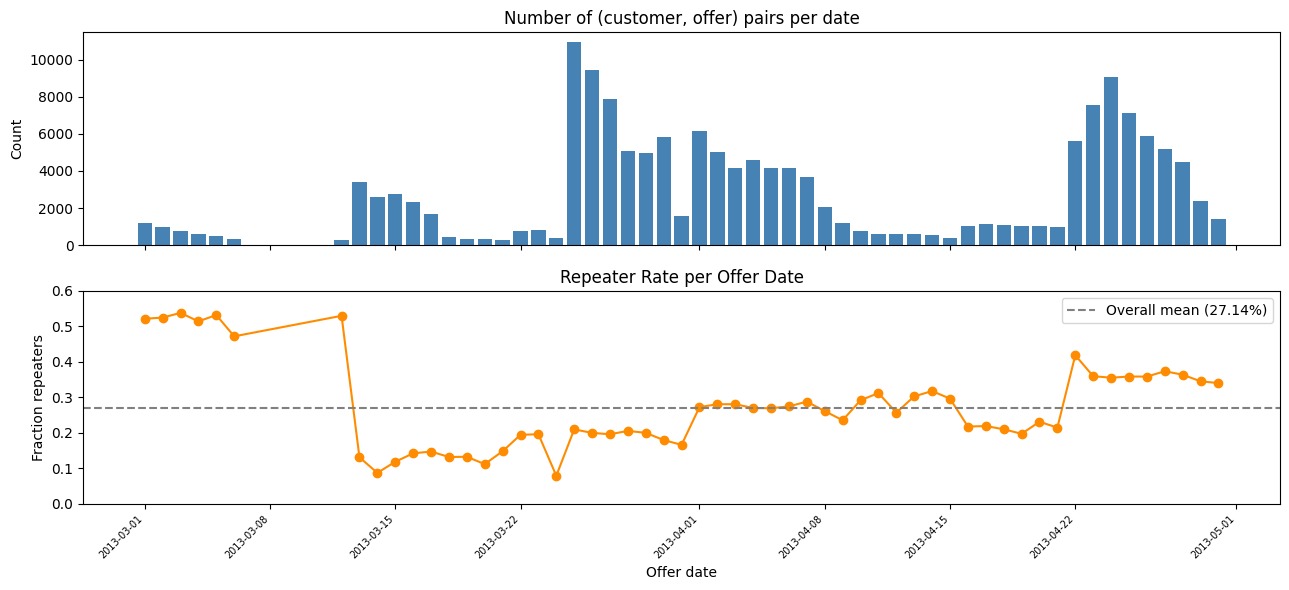

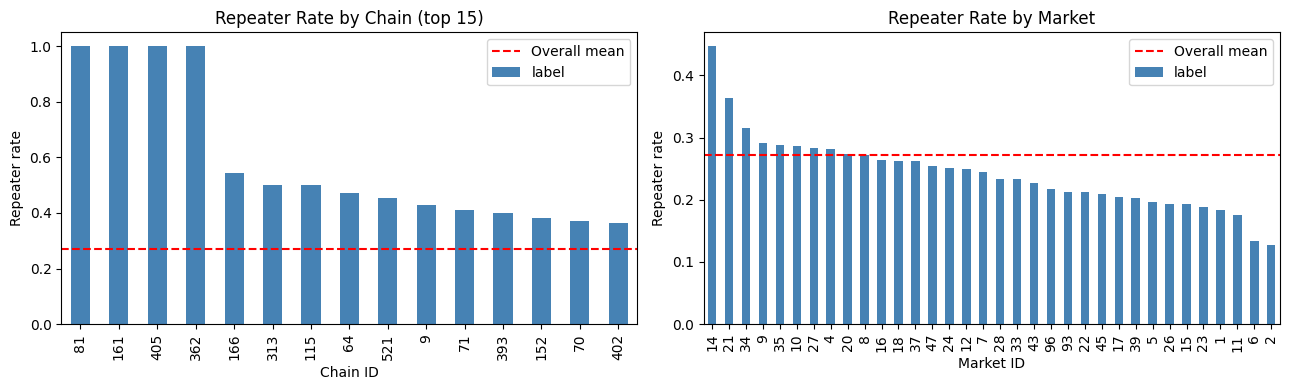

In [19]:
# ── 7.3 Temporal analysis ────────────────────────────────────────────────────
# Offers span March–April 2013.
# The rolling-window experiment depends on temporal ordering:
# knowing whether repeater rates vary by offer date matters for choosing split points.

# Repeater rate by offer date
daily = df.groupby('offerdate').agg(
    n_offers=('label', 'count'),
    repeater_rate=('label', 'mean'),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].bar(daily['offerdate'], daily['n_offers'], color='steelblue', width=0.8)
axes[0].set_title('Number of (customer, offer) pairs per date')
axes[0].set_ylabel('Count')

axes[1].plot(daily['offerdate'], daily['repeater_rate'], marker='o', color='darkorange', linewidth=1.5)
axes[1].axhline(df['label'].mean(), color='grey', linestyle='--', label=f'Overall mean ({df["label"].mean():.2%})')
axes[1].set_title('Repeater Rate per Offer Date')
axes[1].set_ylabel('Fraction repeaters')
axes[1].set_xlabel('Offer date')
axes[1].legend()
axes[1].set_ylim(0, 0.6)

plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

# Repeater rate by chain and market (top 15 chains)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df.groupby('chain')['label'].mean().sort_values(ascending=False).head(15).plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].axhline(df['label'].mean(), color='red', linestyle='--', label='Overall mean')
axes[0].set_title('Repeater Rate by Chain (top 15)')
axes[0].set_ylabel('Repeater rate')
axes[0].set_xlabel('Chain ID')
axes[0].legend()

df.groupby('market')['label'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='steelblue')
axes[1].axhline(df['label'].mean(), color='red', linestyle='--', label='Overall mean')
axes[1].set_title('Repeater Rate by Market')
axes[1].set_ylabel('Repeater rate')
axes[1].set_xlabel('Market ID')
axes[1].legend()

plt.tight_layout()
plt.show()

Top 10 features by normalised mean difference (repeater vs non-repeater):
has_bought_category_a_3     0.5910
has_bought_category_q_3     0.5225
has_bought_brand_a_3        0.5199
has_bought_company_a_3      0.4969
has_bought_brand_q_3        0.4957
has_bought_category_3       0.4829
has_bought_category_a_7     0.4688
has_bought_category_a_14    0.4662
has_bought_category_a_21    0.4597
has_bought_category_a_28    0.4457


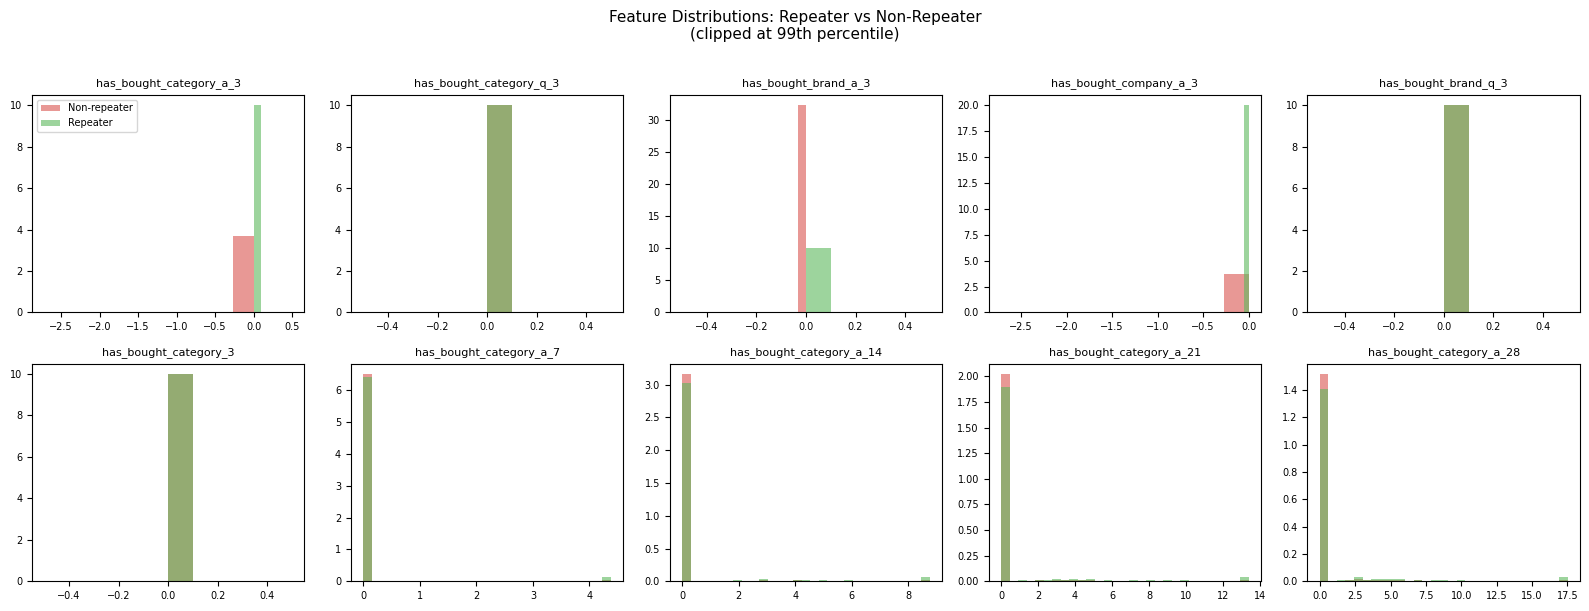

In [20]:
# ── 7.4 Feature distribution overview ───────────────────────────────────────
# Run this cell only after Section 5 has completed (requires X and Y in memory).
# We look at the 10 features with the highest mean absolute difference between
# repeaters and non-repeaters — these are likely to be the most predictive.

if 'X' not in dir() or 'Y' not in dir():
    print("X / Y not found in memory — run sections 1-5 first.")
else:
    X_eda = X.copy()
    X_eda['label'] = Y

    # Mean of each feature split by label
    means = X_eda.groupby('label').mean()
    # Normalised difference: (mean_1 - mean_0) / (mean_1 + mean_0 + 1e-9)
    diff = ((means.loc[1] - means.loc[0]) / (means.loc[1] + means.loc[0] + 1e-9)).abs()
    top10 = diff.sort_values(ascending=False).head(10)

    print("Top 10 features by normalised mean difference (repeater vs non-repeater):")
    print(top10.round(4).to_string())

    fig, axes = plt.subplots(2, 5, figsize=(16, 6))
    axes = axes.flatten()

    for ax, feat in zip(axes, top10.index):
        repeaters_vals     = X_eda.loc[X_eda['label'] == 1, feat]
        non_repeaters_vals = X_eda.loc[X_eda['label'] == 0, feat]
        # Log-scale histogram (many spend/qty features are heavy-tailed)
        q99 = X_eda[feat].quantile(0.99)
        bins = np.linspace(0, q99, 30) if q99 > 0 else 10
        ax.hist(non_repeaters_vals.clip(upper=q99), bins=bins, alpha=0.6,
                label='Non-repeater', color='#d9534f', density=True)
        ax.hist(repeaters_vals.clip(upper=q99), bins=bins, alpha=0.6,
                label='Repeater', color='#5cb85c', density=True)
        ax.set_title(feat, fontsize=8)
        ax.set_xlabel('')
        ax.tick_params(labelsize=7)

    axes[0].legend(fontsize=7)
    plt.suptitle('Feature Distributions: Repeater vs Non-Repeater\n(clipped at 99th percentile)',
                 fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

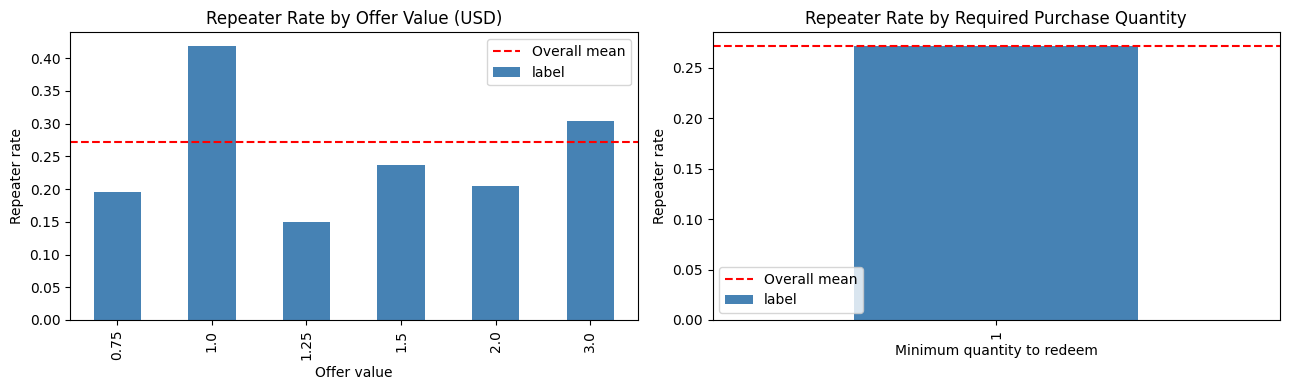

Flag features not yet available — run Section 4 first.


In [21]:
# ── 7.5 Repeater rate conditioned on offer characteristics ──────────────────
# Does the offer value or category affect how likely a customer is to repeat?

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Repeater rate by offer value
df.groupby('offervalue')['label'].mean().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].axhline(df['label'].mean(), color='red', linestyle='--', label='Overall mean')
axes[0].set_title('Repeater Rate by Offer Value (USD)')
axes[0].set_xlabel('Offer value')
axes[0].set_ylabel('Repeater rate')
axes[0].legend()

# Repeater rate by minimum purchase quantity required
df.groupby('quantity')['label'].mean().sort_index().plot(
    kind='bar', ax=axes[1], color='steelblue')
axes[1].axhline(df['label'].mean(), color='red', linestyle='--', label='Overall mean')
axes[1].set_title('Repeater Rate by Required Purchase Quantity')
axes[1].set_xlabel('Minimum quantity to redeem')
axes[1].set_ylabel('Repeater rate')
axes[1].legend()

plt.tight_layout()
plt.show()

# bought_* binary flags vs repeater rate
flag_cols = ['bought_cat', 'bought_brand', 'bought_co', 'bought_cat_brand', 'bought_cat_brand_co']
if all(c in X.columns for c in flag_cols):
    X_flags = X[flag_cols].copy()
    X_flags['label'] = Y
    rates = X_flags.groupby('label')[flag_cols].mean()
    print("\nFraction of customers who had previously bought in each scope:")
    print(rates.T.rename(columns={0: 'Non-repeater', 1: 'Repeater'}).round(3).to_string())
else:
    print("Flag features not yet available — run Section 4 first.")